# Pre-trained Deep Learning Models — Transfer Learning
### Skin Cancer Detection ML Project | Colab-Style Notebook
---
> **Models:** VGG19, ResNet152V2, InceptionV3, ResNet50, DenseNet201
> **Task:** Binary Classification — Benign (0) vs Malignant (1)
> **Strategy:** Transfer learning with frozen ImageNet backbones + custom head

---
## Sections
1. Setup and Imports
2. Load Metadata and Image Paths
3. Train / Validation / Test Split
4. Data Augmentation and Generators
5. Transfer Learning Architecture
6. Training Each Model
7. Evaluation and Confusion Matrices
8. Training History Plots
9. Performance Summary Table


---
## 1. Setup and Imports


In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available : {len(tf.config.list_physical_devices("GPU")) > 0}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs : {gpus}')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f'Enabled dynamic memory growth for {gpu.name}')
        except RuntimeError as e:
            print(e)


TensorFlow version : 2.21.0
GPU available : True
GPUs : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Enabled dynamic memory growth for /physical_device:GPU:0


---
## 2. Load Metadata and Image Paths


In [2]:
import os
import glob
import pandas as pd

# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Running in Google Colab!')
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Metadata path
    METADATA_PATH = 'HAM10000_metadata.csv'
    if not os.path.exists(METADATA_PATH):
        METADATA_PATH = '/content/HAM10000_metadata.csv'
    
    IMAGES_DIR = '/content/drive/MyDrive'
else:
    # Local path resolution
    wsl_path = os.path.expanduser('~/data/HAM10000_metadata.csv')
    if os.path.exists(wsl_path):
        METADATA_PATH = wsl_path
        IMAGES_DIR = os.path.expanduser('~/data')
    elif os.path.exists('data/HAM10000_metadata.csv'):
        METADATA_PATH = 'data/HAM10000_metadata.csv'
        IMAGES_DIR = 'data'
    elif os.path.exists('../data/HAM10000_metadata.csv'):
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR = '../data'
    else:
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR = '../data'

print(f'Metadata Path: {METADATA_PATH}')
print(f'Images Directory: {IMAGES_DIR}')

df = pd.read_csv(METADATA_PATH)

image_paths = []
part1_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_1')
part2_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_2')

if os.path.exists(part1_path):
    image_paths.extend(glob.glob(os.path.join(part1_path, '*.jpg')))
if os.path.exists(part2_path):
    image_paths.extend(glob.glob(os.path.join(part2_path, '*.jpg')))

if len(image_paths) == 0:
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '*.jpg')))

if len(image_paths) == 0:
    if IN_COLAB and IMAGES_DIR == '/content/drive/MyDrive':
        print('[WARNING] Scanning the entire Google Drive recursively might be very slow!')
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '**', '*.jpg'), recursive=True))

image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
df['path'] = df['image_id'].map(image_path_dict.get)
df = df.dropna(subset=['path']).reset_index(drop=True)

lesion_danger = {'nv': 0, 'mel': 1, 'bkl': 0, 'bcc': 1, 'akiec': 1, 'vasc': 0, 'df': 0}
df['target'] = df['dx'].map(lesion_danger)
df['class_str'] = df['target'].astype(str) # needed for flow_from_dataframe

print(f'Dataset: {len(df)} images')
print(df['class_str'].value_counts().to_string())


Metadata Path: /home/shan_ahmedshani/data/HAM10000_metadata.csv
Images Directory: /home/shan_ahmedshani/data
Dataset: 10015 images
class_str
0    8061
1    1954


---
## 3. Train / Validation / Test Split (70 / 15 / 15)


In [3]:
train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['target']
)
train_df, val_df = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df['target']
)

print(f'Train : {len(train_df):5d} images | Benign: {(train_df["target"]==0).sum()} | Malignant: {(train_df["target"]==1).sum()}')
print(f'Val : {len(val_df):5d} images | Benign: {(val_df["target"]==0).sum()} | Malignant: {(val_df["target"]==1).sum()}')
print(f'Test : {len(test_df):5d} images | Benign: {(test_df["target"]==0).sum()} | Malignant: {(test_df["target"]==1).sum()}')


Train :  7235 images | Benign: 5823 | Malignant: 1412
Val :  1277 images | Benign: 1028 | Malignant: 249
Test :  1503 images | Benign: 1210 | Malignant: 293


---
## 4. Data Augmentation and Generators


In [4]:
# ── Augmentation for training ──────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    shear_range=0.05
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 16

def make_generators(target_size=(224, 224)):
    train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col='path', y_col='class_str',
        target_size=target_size, class_mode='binary',
        batch_size=BATCH_SIZE, shuffle=True
    )
    val_gen = val_test_datagen.flow_from_dataframe(
        val_df, x_col='path', y_col='class_str',
        target_size=target_size, class_mode='binary',
        batch_size=BATCH_SIZE, shuffle=False
    )
    test_gen = val_test_datagen.flow_from_dataframe(
        test_df, x_col='path', y_col='class_str',
        target_size=target_size, class_mode='binary',
        batch_size=BATCH_SIZE, shuffle=False
    )
    return train_gen, val_gen, test_gen

# Default generators for 224x224
train_gen, val_gen, test_gen = make_generators(target_size=(224, 224))
print(' Generators ready')


Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
 Generators ready


### 4.2 Data Augmentation Visualization
Here we load a sample image from the training set and visualize the random augmentations applied by `train_datagen` to verify the effect of rotation, shifts, zoom, flips, and shear.


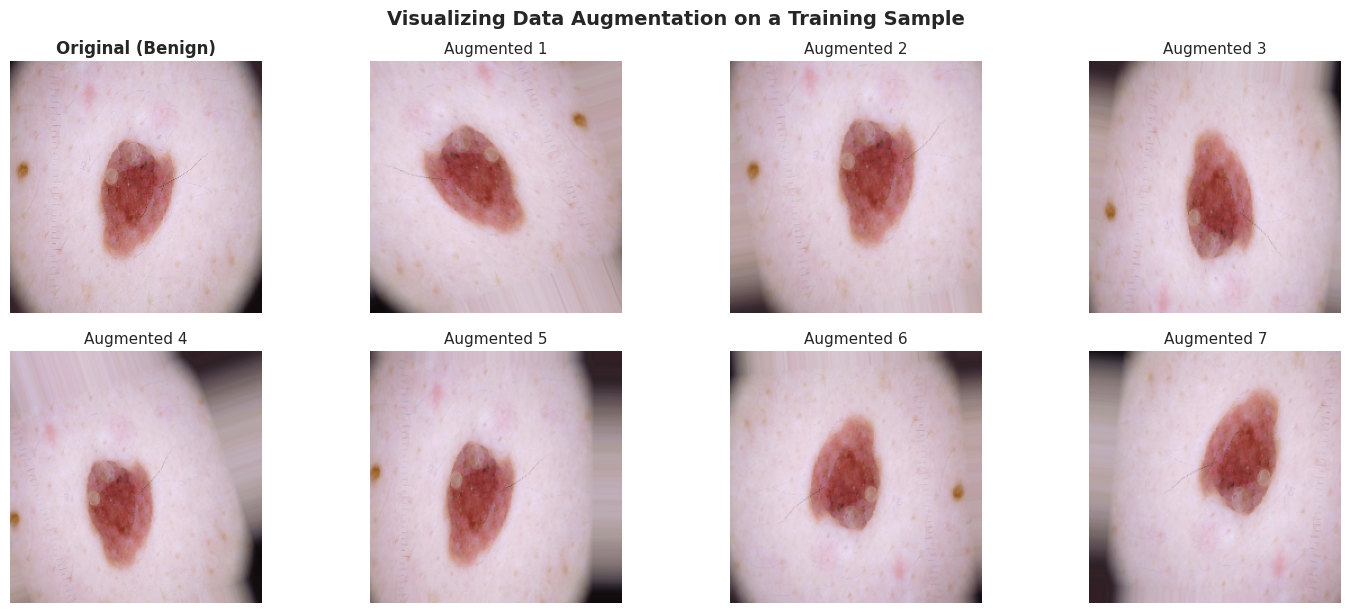

In [5]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Select a sample image from the training dataframe
sample_row = train_df.iloc[0]
sample_path = sample_row['path']
sample_label = 'Malignant' if sample_row['target'] == 1 else 'Benign'

# Load and convert to array
img = load_img(sample_path, target_size=(224, 224))
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # Reshape to (1, 224, 224, 3) for the generator

plt.figure(figsize=(15, 6))

# Plot the original image
plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title(f"Original ({sample_label})", fontsize=12, fontweight='bold')
plt.axis('off')

# Generate and plot 7 augmented variations
i = 2
for batch in train_datagen.flow(x, batch_size=1):
    plt.subplot(2, 4, i)
    # Batch elements are already rescaled to [0,1] due to rescale=1./255 in train_datagen
    plt.imshow(batch[0])
    plt.title(f"Augmented {i-1}", fontsize=11)
    plt.axis('off')
    i += 1
    if i > 8:
        break

plt.tight_layout()
plt.suptitle("Visualizing Data Augmentation on a Training Sample", y=1.02, fontsize=14, fontweight='bold')
plt.show()


---
## 5. Transfer Learning Architecture
Each model uses a **frozen pre-trained backbone** + custom binary classification head:
`GlobalAveragePooling2D → Dense(256, ReLU) → BatchNorm → Dropout(0.4) → Dense(1, Sigmoid)`


In [6]:
def build_transfer_model(backbone_fn, input_shape=(224, 224, 3)):
    base = backbone_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_callbacks():
    return [
        ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
    ]

print(' Transfer learning builder ready')


 Transfer learning builder ready


---
## 6. Training Each Model
> **Note:** Training is set to **15 epochs** (EarlyStopping may stop sooner).
> For full training on a GPU, you can increase to 50+ epochs.


### 6.1 VGG19


In [7]:
from tensorflow.keras.applications import VGG19

model_vgg19 = build_transfer_model(VGG19)
print(f'VGG19 trainable params: {sum(p.numpy().size for p in model_vgg19.trainable_weights):,}')

train_gen_224, val_gen_224, test_gen_224 = make_generators((224, 224))

history_vgg19 = model_vgg19.fit(
    train_gen_224, epochs=15, validation_data=val_gen_224,
    callbacks=get_callbacks(), verbose=1
)


VGG19 trainable params: 132,097
Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Epoch 1/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 122s 248ms/step - accuracy: 0.7205 - loss: 0.5801 - val_accuracy: 0.8230 - val_loss: 0.4266 - learning_rate: 1.0000e-04
Epoch 2/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 99s 218ms/step - accuracy: 0.8053 - loss: 0.4420 - val_accuracy: 0.7150 - val_loss: 0.6027 - learning_rate: 1.0000e-04
Epoch 3/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 95s 210ms/step - accuracy: 0.8070 - loss: 0.4199 - val_accuracy: 0.8160 - val_loss: 0.3845 - learning_rate: 1.0000e-04
Epoch 4/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 95s 209ms/step - accuracy: 0.8178 - loss: 0.4076 - val_accuracy: 0.8168 - val_loss: 0.4122 - learning_rate: 1.0000e-04
Epoch 5/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 94s 207ms/step - accuracy: 0.8134 - loss: 0.4091 - val_accuracy: 0.7948 - val_loss: 0.4483 - learning_rate: 

### 6.2 ResNet50


In [8]:
from tensorflow.keras.applications import ResNet50

model_resnet50 = build_transfer_model(ResNet50)
train_gen_224, val_gen_224, test_gen_224 = make_generators((224, 224))

history_resnet50 = model_resnet50.fit(
    train_gen_224, epochs=15, validation_data=val_gen_224,
    callbacks=get_callbacks(), verbose=1
)


Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Epoch 1/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 118s 226ms/step - accuracy: 0.7462 - loss: 0.5501 - val_accuracy: 0.8050 - val_loss: 0.4576 - learning_rate: 1.0000e-04
Epoch 2/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 86s 190ms/step - accuracy: 0.8076 - loss: 0.4288 - val_accuracy: 0.8066 - val_loss: 0.4908 - learning_rate: 1.0000e-04
Epoch 3/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 87s 191ms/step - accuracy: 0.8104 - loss: 0.4135 - val_accuracy: 0.7643 - val_loss: 0.5012 - learning_rate: 1.0000e-04
Epoch 4/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8057 - loss: 0.4128
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
453/453 ━━━━━━━━━━━━━━━━━━━━ 89s 196ms/step - accuracy: 0.8070 - loss: 0.4090 - val_accuracy: 0.8042 - val_loss: 1.4623 - learning_rate: 1.0000e-04
Epoch 5/15
453/453 ━━━━━━━━

### 6.3 ResNet152V2


In [9]:
from tensorflow.keras.applications import ResNet152V2

model_resnet152v2 = build_transfer_model(ResNet152V2)
train_gen_224, val_gen_224, test_gen_224 = make_generators((224, 224))

history_resnet152v2 = model_resnet152v2.fit(
    train_gen_224, epochs=15, validation_data=val_gen_224,
    callbacks=get_callbacks(), verbose=1
)


Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Epoch 1/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 148s 273ms/step - accuracy: 0.6557 - loss: 0.6890 - val_accuracy: 0.7831 - val_loss: 0.4834 - learning_rate: 1.0000e-04
Epoch 2/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 98s 217ms/step - accuracy: 0.7537 - loss: 0.5118 - val_accuracy: 0.7987 - val_loss: 0.4449 - learning_rate: 1.0000e-04
Epoch 3/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 94s 207ms/step - accuracy: 0.8019 - loss: 0.4389 - val_accuracy: 0.8262 - val_loss: 0.3909 - learning_rate: 1.0000e-04
Epoch 4/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 93s 205ms/step - accuracy: 0.8178 - loss: 0.3993 - val_accuracy: 0.8332 - val_loss: 0.3687 - learning_rate: 1.0000e-04
Epoch 5/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 91s 200ms/step - accuracy: 0.8232 - loss: 0.3863 - val_accuracy: 0.8403 - val_loss: 0.3695 - learning_rate: 1.0000e-04
Epoch 6/15
453/453 ━━

### 6.4 InceptionV3 (input 299×299)


In [10]:
from tensorflow.keras.applications import InceptionV3

model_inceptionv3 = build_transfer_model(InceptionV3, input_shape=(299, 299, 3))
train_gen_299, val_gen_299, test_gen_299 = make_generators((299, 299))

history_inceptionv3 = model_inceptionv3.fit(
    train_gen_299, epochs=15, validation_data=val_gen_299,
    callbacks=get_callbacks(), verbose=1
)


Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Epoch 1/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 172s 337ms/step - accuracy: 0.6756 - loss: 0.6513 - val_accuracy: 0.6601 - val_loss: 0.6679 - learning_rate: 1.0000e-04
Epoch 2/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 132s 290ms/step - accuracy: 0.7732 - loss: 0.4816 - val_accuracy: 0.7987 - val_loss: 0.4295 - learning_rate: 1.0000e-04
Epoch 3/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 133s 293ms/step - accuracy: 0.8108 - loss: 0.4157 - val_accuracy: 0.7431 - val_loss: 0.5286 - learning_rate: 1.0000e-04
Epoch 4/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 135s 299ms/step - accuracy: 0.8180 - loss: 0.3954 - val_accuracy: 0.8199 - val_loss: 0.3953 - learning_rate: 1.0000e-04
Epoch 5/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 132s 291ms/step - accuracy: 0.8304 - loss: 0.3769 - val_accuracy: 0.8238 - val_loss: 0.3822 - learning_rate: 1.0000e-04
Epoch 6/15
453/45

### 6.5 DenseNet201


In [11]:
from tensorflow.keras.applications import DenseNet201

model_densenet201 = build_transfer_model(DenseNet201)
train_gen_224, val_gen_224, test_gen_224 = make_generators((224, 224))

history_densenet201 = model_densenet201.fit(
    train_gen_224, epochs=15, validation_data=val_gen_224,
    callbacks=get_callbacks(), verbose=1
)


Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Epoch 1/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 214s 364ms/step - accuracy: 0.6886 - loss: 0.6488 - val_accuracy: 0.7807 - val_loss: 0.4968 - learning_rate: 1.0000e-04
Epoch 2/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 94s 207ms/step - accuracy: 0.7851 - loss: 0.4681 - val_accuracy: 0.7956 - val_loss: 0.4696 - learning_rate: 1.0000e-04
Epoch 3/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 92s 203ms/step - accuracy: 0.8159 - loss: 0.4112 - val_accuracy: 0.8442 - val_loss: 0.3617 - learning_rate: 1.0000e-04
Epoch 4/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 89s 196ms/step - accuracy: 0.8366 - loss: 0.3741 - val_accuracy: 0.8379 - val_loss: 0.3608 - learning_rate: 1.0000e-04
Epoch 5/15
453/453 ━━━━━━━━━━━━━━━━━━━━ 91s 200ms/step - accuracy: 0.8401 - loss: 0.3594 - val_accuracy: 0.8379 - val_loss: 0.3582 - learning_rate: 1.0000e-04
Epoch 6/15
453/453 ━━

---
## 7. Evaluation and Confusion Matrices


In [12]:
def evaluate_dl_model(name, model, test_gen, target_size=(224, 224)):
    """Evaluate a DL model and return accuracy and classification report."""
    _, test_g, _ = make_generators(target_size=target_size)
    # Reset generator
    test_g.reset()

    y_prob = model.predict(test_g, verbose=0)
    y_pred = (y_prob.ravel() >= 0.5).astype(int)
    y_true = test_g.classes

    acc = (y_pred == y_true).mean()
    rep = classification_report(y_true, y_pred, target_names=['Benign','Malignant'],
                                 output_dict=True, zero_division=0)
    print(f'\n── {name} ──')
    print(f' Accuracy: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Benign','Malignant'], zero_division=0))
    return acc, rep, y_pred, y_true

dl_results = {}

acc_vgg19, rep_vgg19, pred_vgg19, true_vgg19 = evaluate_dl_model(
    'VGG19', model_vgg19, test_gen_224, (224,224))
acc_rn50, rep_rn50, pred_rn50, true_rn50 = evaluate_dl_model(
    'ResNet50', model_resnet50, test_gen_224, (224,224))
acc_rn152, rep_rn152, pred_rn152, true_rn152 = evaluate_dl_model(
    'ResNet152V2', model_resnet152v2, test_gen_224, (224,224))
acc_inc, rep_inc, pred_inc, true_inc = evaluate_dl_model(
    'InceptionV3', model_inceptionv3, test_gen_299, (299,299))
acc_dn201, rep_dn201, pred_dn201, true_dn201 = evaluate_dl_model(
    'DenseNet201', model_densenet201, test_gen_224, (224,224))


Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.

── VGG19 ──
 Accuracy: 0.8293
              precision    recall  f1-score   support

      Benign       0.87      0.93      0.90      1028
   Malignant       0.59      0.41      0.49       249

    accuracy                           0.83      1277
   macro avg       0.73      0.67      0.69      1277
weighted avg       0.81      0.83      0.82      1277

Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.

── ResNet50 ──
 Accuracy: 0.8050
              precision    recall  f1-score   support

      Benign       0.81      1.00      0.89      1028
   Malignant       0.00      0.00      0.00       249

    accuracy                           0.81      1277
   macro avg       0.40 

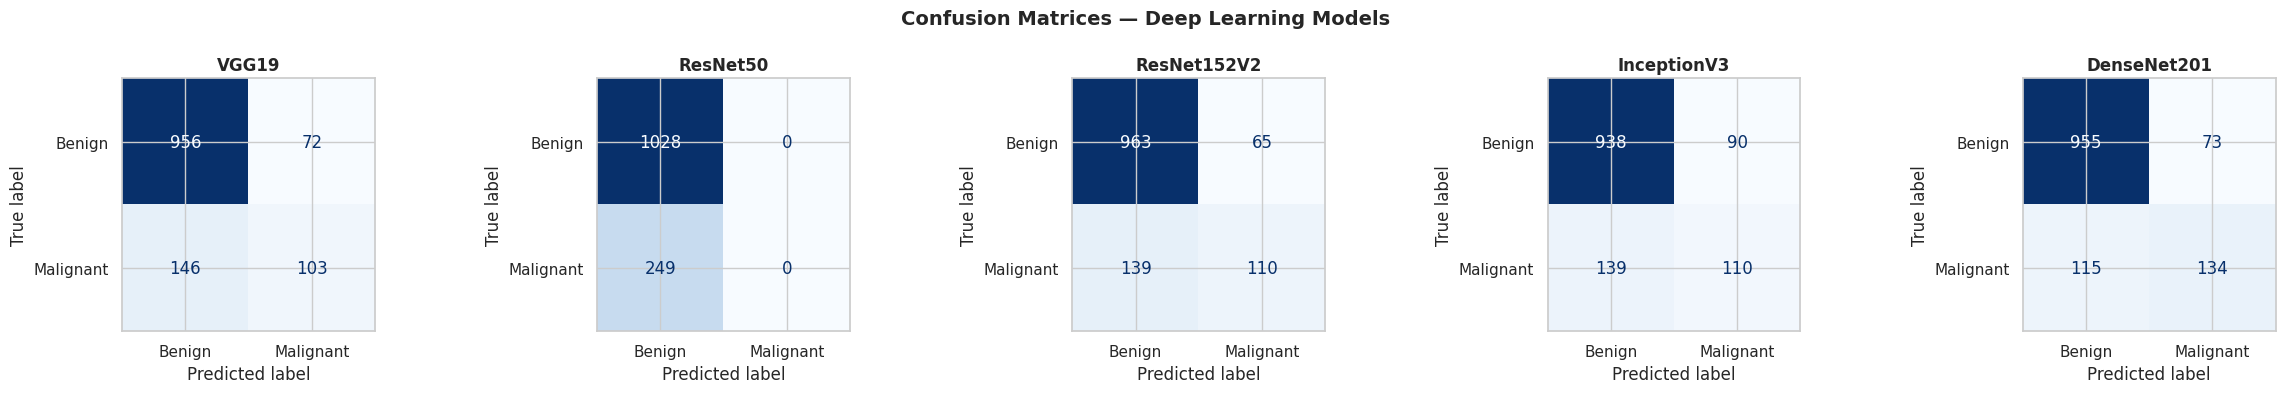

In [13]:
# Confusion matrices for all 5 models
model_eval_list = [
    ('VGG19', pred_vgg19, true_vgg19),
    ('ResNet50', pred_rn50, true_rn50),
    ('ResNet152V2', pred_rn152, true_rn152),
    ('InceptionV3', pred_inc, true_inc),
    ('DenseNet201', pred_dn201, true_dn201),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for i, (name, preds, trues) in enumerate(model_eval_list):
    cm = confusion_matrix(trues, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Deep Learning Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8. Training History Plots


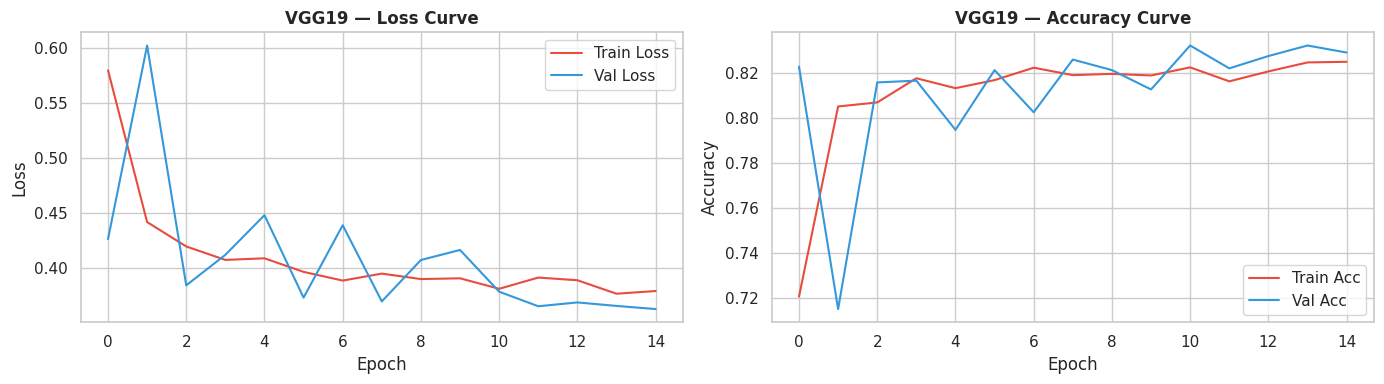

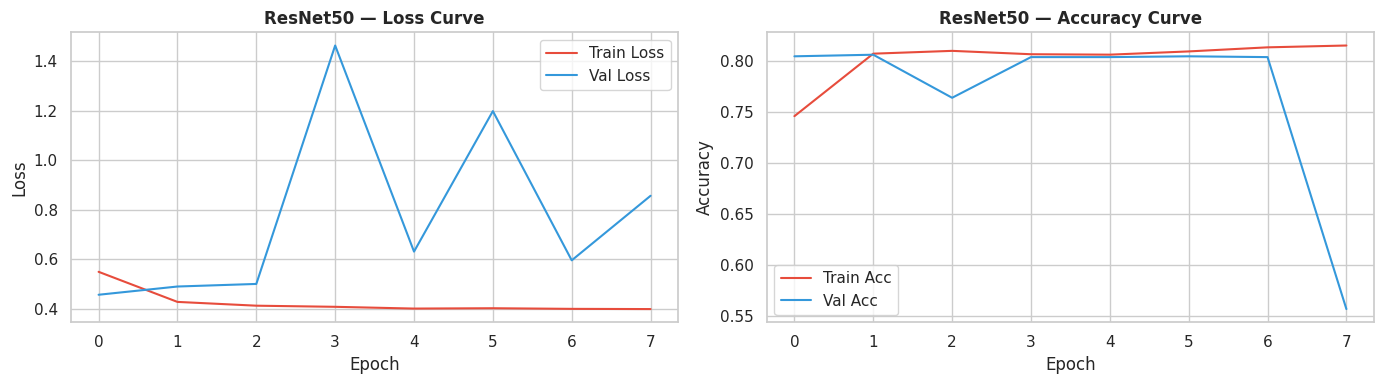

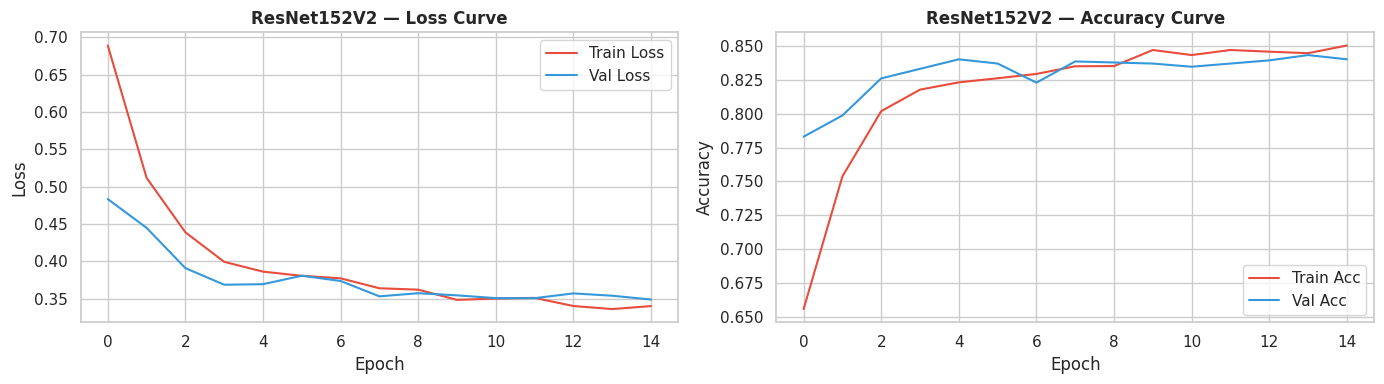

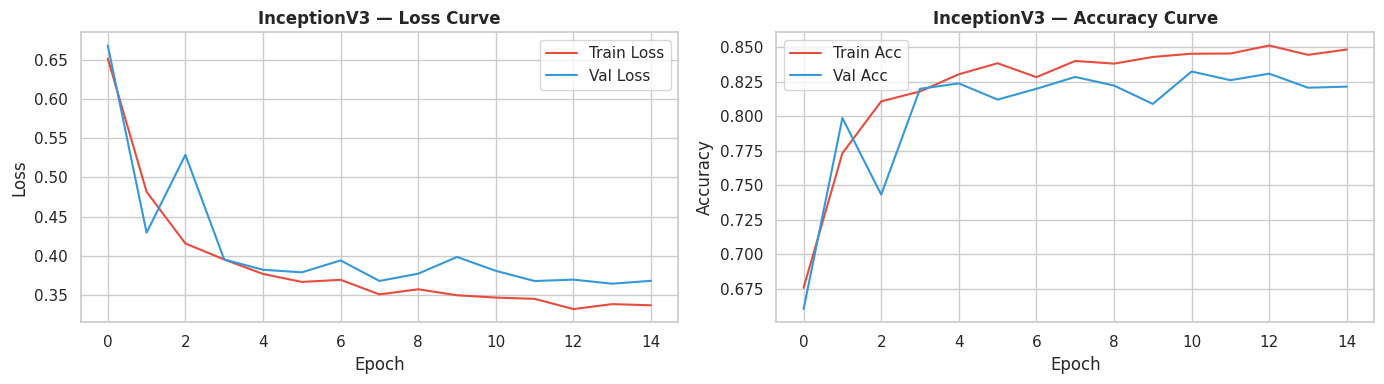

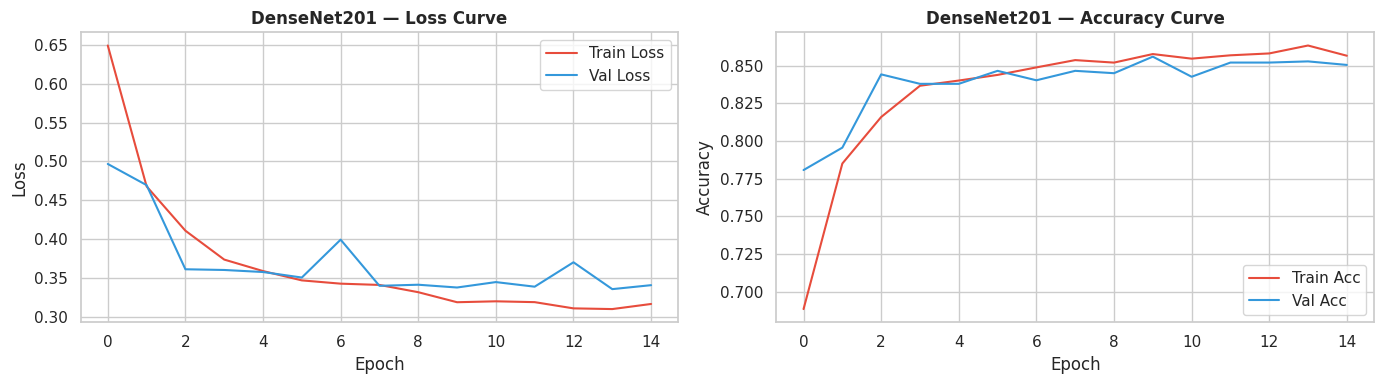

In [14]:
def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['loss'], label='Train Loss', color='#e74c3c')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498db')
    axes[0].set_title(f'{name} — Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Acc', color='#e74c3c')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#3498db')
    axes[1].set_title(f'{name} — Accuracy Curve', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

for hist, name in [
    (history_vgg19, 'VGG19'),
    (history_resnet50, 'ResNet50'),
    (history_resnet152v2, 'ResNet152V2'),
    (history_inceptionv3, 'InceptionV3'),
    (history_densenet201, 'DenseNet201'),
]:
    plot_history(hist, name)


---
## 9. Performance Summary Table


In [15]:
model_accs = {
    'VGG19' : (acc_vgg19, rep_vgg19),
    'ResNet50' : (acc_rn50, rep_rn50),
    'ResNet152V2' : (acc_rn152, rep_rn152),
    'InceptionV3' : (acc_inc, rep_inc),
    'DenseNet201' : (acc_dn201, rep_dn201),
}

rows = []
for name, (acc, rep) in model_accs.items():
    rows.append({
        'Model' : name,
        'Accuracy' : round(acc, 4),
        'B_Precision' : round(rep['Benign']['precision'], 4),
        'B_Recall' : round(rep['Benign']['recall'], 4),
        'B_F1' : round(rep['Benign']['f1-score'], 4),
        'M_Precision' : round(rep['Malignant']['precision'], 4),
        'M_Recall' : round(rep['Malignant']['recall'], 4),
        'M_F1' : round(rep['Malignant']['f1-score'], 4),
    })

summary_dl = pd.DataFrame(rows).set_index('Model')
print('Deep Learning Model Performance Summary:')
print(summary_dl.to_string())
summary_dl


Deep Learning Model Performance Summary:
             Accuracy  B_Precision  B_Recall    B_F1  M_Precision  M_Recall    M_F1
Model                                                                              
VGG19          0.8293       0.8675    0.9300  0.8977       0.5886    0.4137  0.4858
ResNet50       0.8050       0.8050    1.0000  0.8920       0.0000    0.0000  0.0000
ResNet152V2    0.8403       0.8739    0.9368  0.9042       0.6286    0.4418  0.5189
InceptionV3    0.8207       0.8709    0.9125  0.8912       0.5500    0.4418  0.4900
DenseNet201    0.8528       0.8925    0.9290  0.9104       0.6473    0.5382  0.5877


,Accuracy,B_Precision,B_Recall,B_F1,M_Precision,M_Recall,M_F1
Model,,,,,,,
VGG19,0.8293,0.8675,0.9300,0.8977,0.5886,0.4137,0.4858
ResNet50,0.8050,0.8050,1.0000,0.8920,0.0000,0.0000,0.0000
ResNet152V2,0.8403,0.8739,0.9368,0.9042,0.6286,0.4418,0.5189
InceptionV3,0.8207,0.8709,0.9125,0.8912,0.5500,0.4418,0.4900
DenseNet201,0.8528,0.8925,0.9290,0.9104,0.6473,0.5382,0.5877
